Loading LOL dataset from: ./LOL
  Train batches : 60  (486 image pairs)
  Val   batches : 15  (15 image pairs)

Batch shapes  : low=(8, 3, 256, 256)  high=(8, 3, 256, 256)
Value range   : [0.000, 0.545]
Filenames     : ['529.png', '110.png', '528.png', '770.png', '499.png', '628.png', '535.png', '682.png']

Saved sample visualisation → lol_sample.png


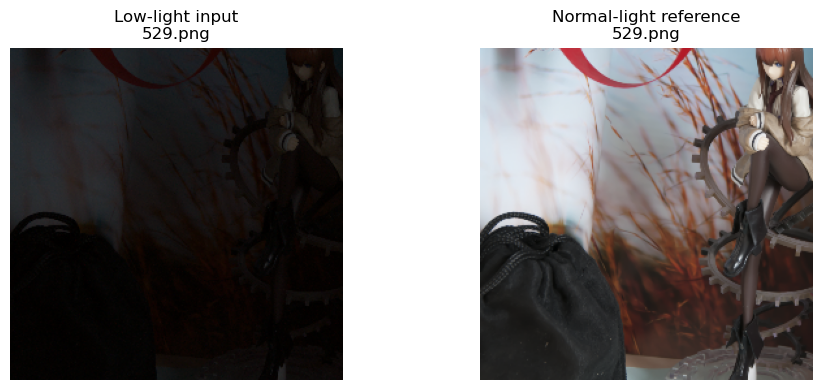

In [28]:

import os
from pathlib import Path
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader  # Fixed 'L'
import torchvision.transforms as T
import torchvision.transforms.functional as TF  # Fixed 'torch' spelling
import random

# ─────────────────────────────────────────────────────────────
# 1.  Core Dataset Class
# ─────────────────────────────────────────────────────────────

class LOLDataset(Dataset):
    """
    Loads paired (low-light, normal-light) images from the LOL dataset.

    Args:
        root      : path to the LOL root folder
        split     : 'train'  → uses our485/
                    'val'    → uses eval15/
        crop_size : if not None, randomly crops both images to this size
                    during training (e.g. 256 or 384).
                    Set to None to use full images (600×400 for LOL).
        augment   : apply random horizontal flip during training
    """

    SPLIT_DIRS = {
        'train': 'our485',
        'val':   'eval15',
    }

    def __init__(
        self,
        root: str,
        split: str = 'train',
        crop_size: int | None = 256,
        augment: bool = True,
    ):
        super().__init__()

        assert split in self.SPLIT_DIRS, f"split must be 'train' or 'val', got '{split}'"

        self.split      = split
        self.crop_size  = crop_size
        self.augment    = augment and (split == 'train')

        split_dir  = Path(root) / self.SPLIT_DIRS[split]
        self.low_dir  = split_dir / 'low'
        self.high_dir = split_dir / 'high'

        self._verify_dirs()

        # Collect filenames — sorted so low/high pairs always align
        self.filenames = sorted(os.listdir(self.low_dir))

        # Sanity check: every low image has a matching high image
        missing = [f for f in self.filenames if not (self.high_dir / f).exists()]
        if missing:
            raise FileNotFoundError(
                f"No matching high-light image for: {missing[:5]} ..."
            )

        # Simple normalisation: PIL image [0,255] → tensor [0,1]
        self.to_tensor = T.ToTensor()

    # ----------------------------------------------------------
    def _verify_dirs(self):
        for d in (self.low_dir, self.high_dir):
            if not d.is_dir():
                raise FileNotFoundError(
                    f"Directory not found: {d}\n"
                    f"Make sure your LOL dataset is at the correct path."
                )

    # ----------------------------------------------------------
    def __len__(self):
        return len(self.filenames)

    # ----------------------------------------------------------
    def __getitem__(self, idx):
        fname = self.filenames[idx]

        # Load images as RGB PIL
        low_img  = Image.open(self.low_dir  / fname).convert('RGB')
        high_img = Image.open(self.high_dir / fname).convert('RGB')

        # ── Random crop (same crop for both images) ──
        if self.crop_size is not None:
            low_img, high_img = self._paired_random_crop(low_img, high_img)

        # ── Random horizontal flip ──
        if self.augment and random.random() > 0.5:
            low_img  = TF.hflip(low_img)
            high_img = TF.hflip(high_img)

        # ── PIL → float tensor [0, 1] ──
        low_tensor  = self.to_tensor(low_img)   # shape: (3, H, W)
        high_tensor = self.to_tensor(high_img)  # shape: (3, H, W)

        return low_tensor, high_tensor, fname

    # ----------------------------------------------------------
    def _paired_random_crop(self, low_pil, high_pil):
        """Apply the SAME random crop to both images."""
        w, h = low_pil.size                          # PIL gives (width, height)
        crop = self.crop_size

        if w < crop or h < crop:
            # If image is smaller than desired crop, just resize both
            low_pil  = TF.resize(low_pil,  [crop, crop])
            high_pil = TF.resize(high_pil, [crop, crop])
            return low_pil, high_pil

        # Random top-left corner
        top  = random.randint(0, h - crop)
        left = random.randint(0, w - crop)

        low_pil  = TF.crop(low_pil,  top, left, crop, crop)
        high_pil = TF.crop(high_pil, top, left, crop, crop)
        return low_pil, high_pil


# ─────────────────────────────────────────────────────────────
# 2.  Convenience Factory Function
# ─────────────────────────────────────────────────────────────

def get_lol_dataloaders(
    root: str,
    batch_size: int = 8,
    crop_size: int | None = 256,
    num_workers: int = 4,
    pin_memory: bool = True,
) -> tuple[DataLoader, DataLoader]:
    """
    Build train and validation DataLoaders for the LOL dataset.

    Args:
        root        : path to the LOL root folder (contains our485/ and eval15/)
        batch_size  : number of image pairs per batch
        crop_size   : random crop size during training. None = full image.
        num_workers : parallel workers for data loading
        pin_memory  : speeds up CPU→GPU transfer (set True when using CUDA)

    Returns:
        (train_loader, val_loader)
    """
    train_set = LOLDataset(root=root, split='train', crop_size=crop_size, augment=True)
    val_set   = LOLDataset(root=root, split='val',   crop_size=None,      augment=False)

    train_loader = DataLoader(
        train_set,
        batch_size  = batch_size,
        shuffle     = True,          # shuffle every epoch
        num_workers = num_workers,
        pin_memory  = pin_memory,
        drop_last   = True,          # keeps batch size consistent
    )

    val_loader = DataLoader(
        val_set,
        batch_size  = 1,             # validate one image at a time (full resolution)
        shuffle     = False,
        num_workers = num_workers,
        pin_memory  = pin_memory,
        drop_last   = False,
    )

    return train_loader, val_loader


# ─────────────────────────────────────────────────────────────
# 3.  Quick Sanity Check  (run this file directly to test)
# ─────────────────────────────────────────────────────────────

if __name__ == '__main__':
    import sys
    import matplotlib.pyplot as plt

    # ── Point this at your LOL folder ──
    LOL_ROOT = './LOL'   # <-- change this if your path is different

    print(f"Loading LOL dataset from: {LOL_ROOT}")

    try:
        train_loader, val_loader = get_lol_dataloaders(
            root='./LOL',
            batch_size  = 8,
            pin_memory=False,
            num_workers = 0,   # 0 = no multiprocessing (safer for quick test)
        )
    except FileNotFoundError as e:
        print(f"\n[ERROR] {e}")
        sys.exit(1)

    print(f"  Train batches : {len(train_loader)}  "
          f"({len(train_loader.dataset)} image pairs)")
    print(f"  Val   batches : {len(val_loader)}  "
          f"({len(val_loader.dataset)} image pairs)")

    # ── Grab one batch and print tensor info ──
    low_batch, high_batch, fnames = next(iter(train_loader))

    print(f"\nBatch shapes  : low={tuple(low_batch.shape)}  "
          f"high={tuple(high_batch.shape)}")
    print(f"Value range   : [{low_batch.min():.3f}, {low_batch.max():.3f}]")
    print(f"Filenames     : {list(fnames)}")

    # ── Visualise the first pair ──
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    # Convert tensor (C,H,W) → numpy (H,W,C) for matplotlib
    axes[0].imshow(low_batch[0].permute(1, 2, 0).numpy())
    axes[0].set_title(f'Low-light input\n{fnames[0]}')
    axes[0].axis('off')

    axes[1].imshow(high_batch[0].permute(1, 2, 0).numpy())
    axes[1].set_title(f'Normal-light reference\n{fnames[0]}')
    axes[1].axis('off')

    plt.tight_layout()
    plt.savefig('lol_sample.png', dpi=120)
    print("\nSaved sample visualisation → lol_sample.png")
    plt.show()

In [11]:
"""
Low-Light Enhancement Network (LLEN)
=====================================
A U-Net style encoder-decoder with skip connections and residual blocks.
 
Architecture overview:
 
    Input (3, H, W)
        │
    ┌───▼────────────────────────────────────┐
    │  Encoder                               │
    │  E1: Conv → ResBlock  (32 ch, H/1)    │──── skip1
    │  E2: Down → ResBlock  (64 ch, H/2)    │──── skip2
    │  E3: Down → ResBlock  (128 ch, H/4)   │──── skip3
    │  E4: Down → ResBlock  (256 ch, H/8)   │──── skip4
    └───────────────────────────────────────-┘
        │
    ┌───▼────────────────────────────────────┐
    │  Bottleneck: ResBlock × 2  (256 ch)    │
    └───────────────────────────────────────-┘
        │
    ┌───▼────────────────────────────────────┐
    │  Decoder  (skip connections injected)  │
    │  D4: Up + skip4 → ResBlock (128 ch)   │  ← DGFF feedback injected here (P5)
    │  D3: Up + skip3 → ResBlock (64 ch)    │  ← DGFF feedback injected here (P4)
    │  D2: Up + skip2 → ResBlock (32 ch)    │
    │  D1: Up + skip1 → ResBlock (32 ch)    │
    └───────────────────────────────────────-┘
        │
    Output head: Conv 1×1 → sigmoid → (3, H, W)
 
The decoder stages D4 and D3 are where the DGFF module will later inject
YOLOv8 backbone feature maps (P5 and P4 respectively). The injection points
are clearly marked with comments so you know exactly where to add them.
 
Usage:
    from llen import LLEN
    model = LLEN()
    enhanced = model(low_img)   # (B, 3, H, W) → (B, 3, H, W)
 
Standalone training:
    python llen.py          # trains on LOL for a few epochs as a smoke test
"""

'\nLow-Light Enhancement Network (LLEN)\n=====================================\nA U-Net style encoder-decoder with skip connections and residual blocks.\n\nArchitecture overview:\n\n    Input (3, H, W)\n        │\n    ┌───▼────────────────────────────────────┐\n    │  Encoder                               │\n    │  E1: Conv → ResBlock  (32 ch, H/1)    │──── skip1\n    │  E2: Down → ResBlock  (64 ch, H/2)    │──── skip2\n    │  E3: Down → ResBlock  (128 ch, H/4)   │──── skip3\n    │  E4: Down → ResBlock  (256 ch, H/8)   │──── skip4\n    └───────────────────────────────────────-┘\n        │\n    ┌───▼────────────────────────────────────┐\n    │  Bottleneck: ResBlock × 2  (256 ch)    │\n    └───────────────────────────────────────-┘\n        │\n    ┌───▼────────────────────────────────────┐\n    │  Decoder  (skip connections injected)  │\n    │  D4: Up + skip4 → ResBlock (128 ch)   │  ← DGFF feedback injected here (P5)\n    │  D3: Up + skip3 → ResBlock (64 ch)    │  ← DGFF feedback inject

In [29]:
%%writefile lol_dataset.py

import torch
import torch.nn as nn
import torch.nn.functional as F

# ─────────────────────────────────────────────────────────────
# 1.  Core Dataset Class
# ─────────────────────────────────────────────────────────────
 
class LOLDataset(Dataset):
    """
    Loads paired (low-light, normal-light) images from the LOL dataset.
 
    Args:
        root      : path to the LOL root folder
        split     : 'train'  → uses our485/
                    'val'    → uses eval15/
        crop_size : if not None, randomly crops both images to this size
                    during training (e.g. 256 or 384).
                    Set to None to use full images (600×400 for LOL).
        augment   : apply random horizontal flip during training
    """
 
    SPLIT_DIRS = {
        'train': 'our485',
        'val':   'eval15',
    }
 
    def __init__(
        self,
        root: str,
        split: str = 'train',
        crop_size: int | None = 256,
        augment: bool = True,
    ):
        super().__init__()
 
        assert split in self.SPLIT_DIRS, f"split must be 'train' or 'val', got '{split}'"
 
        self.split      = split
        self.crop_size  = crop_size
        self.augment    = augment and (split == 'train')
 
        split_dir  = Path(root) / self.SPLIT_DIRS[split]
        self.low_dir  = split_dir / 'low'
        self.high_dir = split_dir / 'high'
 
        self._verify_dirs()
 
        # Collect filenames — sorted so low/high pairs always align
        # Filter to image files only (excludes .DS_Store and other macOS metadata)
        _IMG_EXTS = {'.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'}
        self.filenames = sorted(
            f for f in os.listdir(self.low_dir)
            if Path(f).suffix.lower() in _IMG_EXTS
        )
 
        # Sanity check: every low image has a matching high image
        missing = [f for f in self.filenames if not (self.high_dir / f).exists()]
        if missing:
            raise FileNotFoundError(
                f"No matching high-light image for: {missing[:5]} ..."
            )
 
        # Simple normalisation: PIL image [0,255] → tensor [0,1]
        self.to_tensor = T.ToTensor()
 
    # ----------------------------------------------------------
    def _verify_dirs(self):
        for d in (self.low_dir, self.high_dir):
            if not d.is_dir():
                raise FileNotFoundError(
                    f"Directory not found: {d}\n"
                    f"Make sure your LOL dataset is at the correct path."
                )
 
    # ----------------------------------------------------------
    def __len__(self):
        return len(self.filenames)
 
    # ----------------------------------------------------------
    def __getitem__(self, idx):
        fname = self.filenames[idx]
 
        # Load images as RGB PIL
        low_img  = Image.open(self.low_dir  / fname).convert('RGB')
        high_img = Image.open(self.high_dir / fname).convert('RGB')
 
        # ── Random crop (same crop for both images) ──
        if self.crop_size is not None:
            low_img, high_img = self._paired_random_crop(low_img, high_img)
 
        # ── Random horizontal flip ──
        if self.augment and random.random() > 0.5:
            low_img  = TF.hflip(low_img)
            high_img = TF.hflip(high_img)
 
        # ── PIL → float tensor [0, 1] ──
        low_tensor  = self.to_tensor(low_img)   # shape: (3, H, W)
        high_tensor = self.to_tensor(high_img)  # shape: (3, H, W)
 
        return low_tensor, high_tensor, fname
 
    # ----------------------------------------------------------
    def _paired_random_crop(self, low_pil, high_pil):
        """Apply the SAME random crop to both images."""
        w, h = low_pil.size                          # PIL gives (width, height)
        crop = self.crop_size
 
        if w < crop or h < crop:
            # If image is smaller than desired crop, just resize both
            low_pil  = TF.resize(low_pil,  [crop, crop])
            high_pil = TF.resize(high_pil, [crop, crop])
            return low_pil, high_pil
 
        # Random top-left corner
        top  = random.randint(0, h - crop)
        left = random.randint(0, w - crop)
 
        low_pil  = TF.crop(low_pil,  top, left, crop, crop)
        high_pil = TF.crop(high_pil, top, left, crop, crop)
        return low_pil, high_pil
 
 
# ─────────────────────────────────────────────────────────────
# 2.  Convenience Factory Function
# ─────────────────────────────────────────────────────────────
 
def get_lol_dataloaders(
    root: str,
    batch_size: int = 8,
    crop_size: int | None = 256,
    num_workers: int = 0,   # 0 = safe for Jupyter notebooks on Mac/Windows
    pin_memory: bool = False,  # False = safe for MPS (Apple Silicon) and CPU
) -> tuple[DataLoader, DataLoader]:
    """
    Build train and validation DataLoaders for the LOL dataset.
 
    Args:
        root        : path to the LOL root folder (contains our485/ and eval15/)
        batch_size  : number of image pairs per batch
        crop_size   : random crop size during training. None = full image.
        num_workers : parallel workers for data loading
        pin_memory  : speeds up CPU→GPU transfer (set True when using CUDA)
 
    Returns:
        (train_loader, val_loader)
    """
    train_set = LOLDataset(root=root, split='train', crop_size=crop_size, augment=True)
    val_set   = LOLDataset(root=root, split='val',   crop_size=None,      augment=False)
 
    train_loader = DataLoader(
        train_set,
        batch_size  = batch_size,
        shuffle     = True,          # shuffle every epoch
        num_workers = num_workers,
        pin_memory  = pin_memory,
        drop_last   = True,          # keeps batch size consistent
    )
 
    val_loader = DataLoader(
        val_set,
        batch_size  = 1,             # validate one image at a time (full resolution)
        shuffle     = False,
        num_workers = num_workers,
        pin_memory  = pin_memory,
        drop_last   = False,
    )
 
    return train_loader, val_loader
 
 
# ─────────────────────────────────────────────────────────────
# 3.  Quick Sanity Check  (run this file directly to test)
# ─────────────────────────────────────────────────────────────
 
if __name__ == '__main__':
    import sys
    import matplotlib.pyplot as plt
 
    # ── Point this at your LOL folder ──
    LOL_ROOT = './LOL'   # <-- change this if your path is different
 
    print(f"Loading LOL dataset from: {LOL_ROOT}")
 
    try:
        train_loader, val_loader = get_lol_dataloaders(
            root        = LOL_ROOT,
            batch_size  = 4,
            crop_size   = 256,
            num_workers = 0,      # always 0 when running directly as __main__
            pin_memory  = False,  # False for MPS (Apple Silicon) and CPU
        )
    except FileNotFoundError as e:
        print(f"\n[ERROR] {e}")
        sys.exit(1)
 
    print(f"  Train batches : {len(train_loader)}  "
          f"({len(train_loader.dataset)} image pairs)")
    print(f"  Val   batches : {len(val_loader)}  "
          f"({len(val_loader.dataset)} image pairs)")
 
    # ── Grab one batch and print tensor info ──
    low_batch, high_batch, fnames = next(iter(train_loader))
 
    print(f"\nBatch shapes  : low={tuple(low_batch.shape)}  "
          f"high={tuple(high_batch.shape)}")
    print(f"Value range   : [{low_batch.min():.3f}, {low_batch.max():.3f}]")
    print(f"Filenames     : {list(fnames)}")
 
    # ── Visualise the first pair ──
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    # Convert tensor (C,H,W) → numpy (H,W,C) for matplotlib
    axes[0].imshow(low_batch[0].permute(1, 2, 0).numpy())
    axes[0].set_title(f'Low-light input\n{fnames[0]}')
    axes[0].axis('off')
 
    axes[1].imshow(high_batch[0].permute(1, 2, 0).numpy())
    axes[1].set_title(f'Normal-light reference\n{fnames[0]}')
    axes[1].axis('off')
 
    plt.tight_layout()
    plt.savefig('lol_sample.png', dpi=120)
    print("\nSaved sample visualisation → lol_sample.png")
    plt.show()
 

Overwriting lol_dataset.py


In [19]:
"""
Detection-Guided Feature Feedback (DGFF) Module
================================================
The DGFF module is the core architectural contribution of this thesis.
 
During training it:
  1. Hooks into the YOLOv8 backbone to extract intermediate feature maps
     at P4 (stride-16) and P5 (stride-32) — the semantically richest layers.
  2. Projects each feature map to match the channel depth of the corresponding
     LLEN decoder stage via lightweight 1×1 convolutional adapters.
  3. Returns the projected tensors so LLEN.forward() can inject them via
     element-wise addition at decoder stages D4 and D3.
 
At inference the DGFF module is NOT used — LLEN runs alone with no overhead.
 
YOLOv8n backbone channel dimensions (verified for 640×640 input):
  P4: (B, 256, H/16, W/16)   stride-16, semantically rich
  P5: (B, 512, H/32, W/32)   stride-32, most semantic
 
LLEN decoder injection targets:
  dec4 output: (B, 128, H/8,  W/8)   ← receives projected P5
  dec3 output: (B,  64, H/4,  W/4)   ← receives projected P4
 
Data flow during training:
  low_img
    │
    ▼
  LLEN encoder → bottleneck
    │                          YOLOv8 backbone
    │         enhanced_img ──────────────────────► P4 (256ch)
    │              ▲                             ► P5 (512ch)
    │              │                                  │
    │         LLEN head                          DGFF adapters
    │              ▲                            P4→64ch, P5→128ch
    │              │                                  │
    └── dec1 ◄ dec2 ◄ dec3 ◄──────── dgff_p4        │
                         dec4 ◄──────────────── dgff_p5
                              (element-wise +)
 
Usage:
    from dgff import DGFFModule
    dgff = DGFFModule()
 
    # During joint training forward pass:
    enhanced        = llen(low_img)                      # first pass: no feedback
    dgff_p4, dgff_p5 = dgff(enhanced)                   # extract + project features
    enhanced        = llen(low_img, dgff_p5, dgff_p4)   # second pass: with feedback
    loss            = detection_loss + l1_loss(enhanced, high_img)
    loss.backward()
"""
 

'\nDetection-Guided Feature Feedback (DGFF) Module\n================================================\nThe DGFF module is the core architectural contribution of this thesis.\n\nDuring training it:\n  1. Hooks into the YOLOv8 backbone to extract intermediate feature maps\n     at P4 (stride-16) and P5 (stride-32) — the semantically richest layers.\n  2. Projects each feature map to match the channel depth of the corresponding\n     LLEN decoder stage via lightweight 1×1 convolutional adapters.\n  3. Returns the projected tensors so LLEN.forward() can inject them via\n     element-wise addition at decoder stages D4 and D3.\n\nAt inference the DGFF module is NOT used — LLEN runs alone with no overhead.\n\nYOLOv8n backbone channel dimensions (verified for 640×640 input):\n  P4: (B, 256, H/16, W/16)   stride-16, semantically rich\n  P5: (B, 512, H/32, W/32)   stride-32, most semantic\n\nLLEN decoder injection targets:\n  dec4 output: (B, 128, H/8,  W/8)   ← receives projected P5\n  dec3 outp

In [30]:
%%writefile llen.py
import torch
import torch.nn as nn
import torch.nn.functional as F
from ultralytics import YOLO

# ── PASTE THIS into your DGFF smoke-test cell, replacing the import block ──
#
# The problem: your notebook has all code in cells, so there is no llen.py
# file on disk to import. LLEN is already defined in a previous cell though,
# so we just skip the import entirely and use it directly.
#
# BEFORE (broken):
#   sys.path.insert(0, str(Path(__file__).parent if '__file__' in dir() else Path('.')))
#   from llen import LLEN
#
# AFTER (fixed) — replace those two lines with:

# Check if LLEN is already defined in this notebook session
if 'LLEN' not in dir():
    # Only needed if running dgff.py as a standalone script
    import sys
    sys.path.insert(0, '.')   # assumes llen.py is in the same folder as notebook
    from llen import LLEN

# Everything below stays exactly the same
llen_model = LLEN(base_ch=32).to(device)

# Pass 1: LLEN enhances without feedback
enhanced = llen_model(dummy_enhanced)
print(f"  Pass 1 enhanced : {tuple(enhanced.shape)}")

# Pass 2: DGFF extracts features from enhanced image
dgff_p4, dgff_p5 = dgff_v2(enhanced)

# Pass 3: LLEN re-enhances with detection feedback injected
enhanced_guided = llen_model(dummy_enhanced, dgff_p5=dgff_p5, dgff_p4=dgff_p4)
print(f"  Pass 2 guided   : {tuple(enhanced_guided.shape)}")

assert enhanced_guided.shape == dummy_enhanced.shape
print("  Combined pipeline ✓")

# ── Gradient flow test ──────────────────────────────────────
print("\n  Testing gradient flow through DGFF adapters ...")

llen_model.train()
dgff_v2.train()

enhanced         = llen_model(dummy_enhanced)
dgff_p4, dgff_p5 = dgff(enhanced)
enhanced_guided  = llen_model(dummy_enhanced, dgff_p5=dgff_p5, dgff_p4=dgff_p4)

dummy_target = torch.rand_like(enhanced_guided)
loss = torch.nn.functional.l1_loss(enhanced_guided, dummy_target)
loss.backward()

for name, param in dgff.adapter_p5.named_parameters():
    assert param.grad is not None, f"adapter_p5.{name} has no gradient!"
for name, param in dgff.adapter_p4.named_parameters():
    assert param.grad is not None, f"adapter_p4.{name} has no gradient!"

print("  Adapter gradients flowing ✓")
print("\n  All DGFF tests passed ✓")

Overwriting llen.py
